# Michaelis Menten & Hill Kinetics

Michaelis Menten (MM) and Hill kinetics in vitro (closed system). MM is nonlinear but monotonous. Hill with n>1 is nonlinear with a qualitative transition, the inflection point. Predict n=1 -> n=4 sigmoidal changes in open flow. Open flow and nonlinearity are the basic ingredients of every complex living systems. Concept: mathematical treatment of nonlinear functions.

In [3]:
import plotly.graph_objects as go
from matplotlib.pyplot import subplots, figure
from numpy.random import default_rng
from numpy import arange, linspace, meshgrid, zeros_like, gradient, array, logspace

## Rate function definition


In [4]:
def menten_hill_kinetics(S, k_max, K_m, n):
    """
    Hill kinetics equation; reduces to Michaelis-Menten for n=1
    S: substrate concentration
    k_max: maximum reaction rate (includes enzyme concentration)
    K_m: Michaelis constant (fixed at 1)
    n: Hill coefficient (exponent of cooperativity, positive real number)
    """

    rate = (k_max * S**n) / (K_m**n + S**n)
    
    return rate


## Basic Enzyme Kinetics


Enzyme Kinetics without and with cooperativity
Parameters: k_max = 1, K_m = 1

Key observations:
1. n = 1: Classic hyperbolic Michaelis-Menten kinetics
2. n > 1: Positive cooperativity - sigmoidal curves
3. n >> 1: Switch-like behavior - very steep transition
5. Half-maximal rate at S = K_m = 1

 Change from hyperbolic (blue) to switch-like(orange, red) shape
 


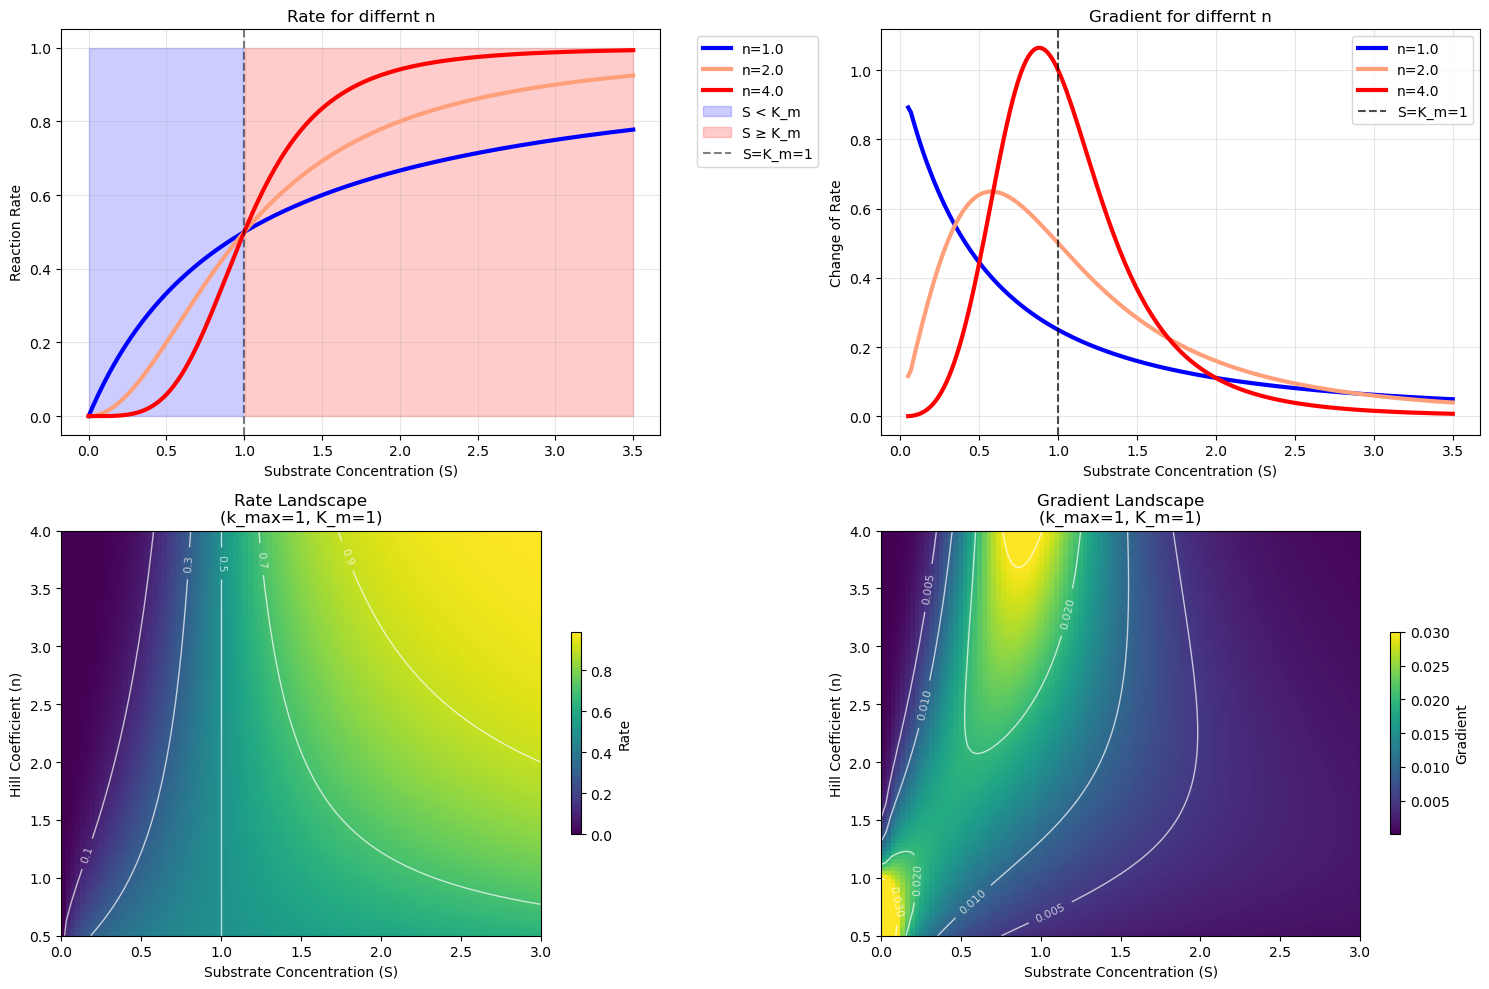

In [5]:
# Parameters
K_m   = 1
k_max = 1

# Ranges for substrate and Hill coefficient
S_values = linspace(0,   3, 100)  
n_values = linspace(0.5, 4, 100)

# Meshgrid of S and n
S, N = meshgrid(S_values, n_values)

# Reaction rate and its gradient
rate_landscape = zeros_like(S)
for i in range(S.shape[0]):
    for j in range(S.shape[1]):
        rate_landscape[i,j] = menten_hill_kinetics(S[i,j], k_max, K_m, N[i,j])

rate_landscape_gradient = gradient(rate_landscape)


# Plot
fig = figure(figsize=(15, 10))

# 1. Impact of cooperativity on reaction rate
ax1 = fig.add_subplot(2, 2, 1)

S_fine = linspace(0, 3.5, 300)
n_transition = [1.0, 2.0, 4.0]
colors = ['blue', 'lightsalmon', 'red']

for n, color in zip(n_transition, colors):
    rate = menten_hill_kinetics(S_fine, k_max, K_m, n)
    ax1.plot(S_fine, rate, color=color, linewidth=3, label=f'n={n}')

# Annotations
ax1.fill_between(S_fine, 0, 1, where=(S_fine<1), alpha=0.2, color='blue', label='S < K_m')
ax1.fill_between(S_fine, 0, 1, where=(S_fine>=1), alpha=0.2, color='red', label='S ≥ K_m')
ax1.axvline(x=1, color='black', linestyle='--', alpha=0.5, label='S=K_m=1')

ax1.set_xlabel('Substrate Concentration (S)')
ax1.set_ylabel('Reaction Rate')
ax1.set_title('Rate for differnt n')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)


# 2. Impact of cooperativity on derivative of reaction rate
ax2 = fig.add_subplot(2, 2, 2)

S_analysis = linspace(0.05, 3.5, 200)

for ind, n in enumerate([1.0, 2.0, 4.0]):
    rate = menten_hill_kinetics(S_analysis, k_max, K_m, n)
    derivative = gradient(rate, S_analysis)
    ax2.plot(S_analysis, derivative, label=f'n={n}', color=colors[ind], linewidth=3)

ax2.axvline(x=1, color='black', linestyle='--', alpha=0.7, label='S=K_m=1')
ax2.set_xlabel('Substrate Concentration (S)')
ax2.set_ylabel('Change of Rate')
ax2.set_title('Gradient for differnt n')
ax2.legend()
ax2.grid(True, alpha=0.3)



# 3. Rate Landscape (S vs n)
ax3 = fig.add_subplot(2, 2, 3)

im3 = ax3.imshow(rate_landscape, extent=[S_values.min(), S_values.max(), 
                                       n_values.min(), n_values.max()],
               origin='lower', aspect='auto', cmap='viridis')
ax3.set_xlabel('Substrate Concentration (S)')
ax3.set_ylabel('Hill Coefficient (n)')
ax3.set_title(f'Rate Landscape\n(k_max={k_max}, K_m={K_m})')

fig.colorbar(im3, ax=ax3, label='Rate', shrink=0.5)

contour_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
contours = ax3.contour(S, N, rate_landscape, levels=contour_levels, 
                       colors='white', alpha=0.7, linewidths=1)
ax3.clabel(contours, inline=True, fontsize=8, fmt='%.1f')


# 4. Derivative of Rate Landscape
ax4 = fig.add_subplot(2, 2, 4)

im4 = ax4.imshow(rate_landscape_gradient[1], extent=[S_values.min(), S_values.max(), 
                                       n_values.min(), n_values.max()], vmax=0.03,
               origin='lower', aspect='auto', cmap='viridis')
ax4.set_xlabel('Substrate Concentration (S)')
ax4.set_ylabel('Hill Coefficient (n)')
ax4.set_title(f'Gradient Landscape\n(k_max={k_max}, K_m={K_m})')
fig.colorbar(im4, ax=ax4, label='Gradient', shrink=0.5)

# Add contour lines
contour_levels_gradient = [0.005, 0.01, 0.02, 0.03]
contours_grad = ax4.contour(S, N, rate_landscape_gradient[1], levels=contour_levels_gradient, 
                       colors='white', alpha=0.7, linewidths=1)
ax4.clabel(contours_grad, inline=True, fontsize=8, fmt='%.3f')


fig.tight_layout()



# Print analysis
print("Enzyme Kinetics without and with cooperativity")
print("=" * 50)
print(f"Parameters: k_max = {k_max}, K_m = {K_m}")
print("\nKey observations:")
print("1. n = 1: Classic hyperbolic Michaelis-Menten kinetics")
print("2. n > 1: Positive cooperativity - sigmoidal curves")
print("3. n >> 1: Switch-like behavior - very steep transition")
print(f"5. Half-maximal rate at S = K_m = {K_m}")
print("\n Change from hyperbolic (blue) to switch-like(orange, red) shape")
print(' ')


## Interactive Slider widget

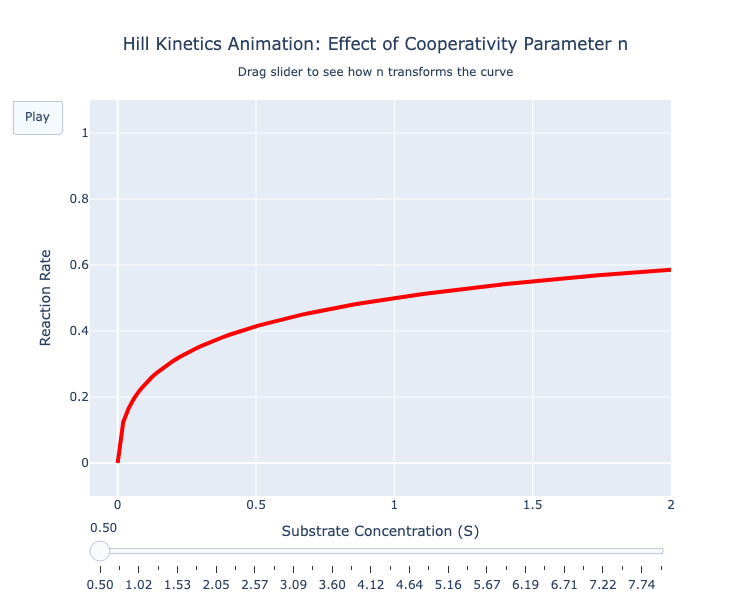

In [6]:
S_values = linspace(0, 2, 100)  # substrate range

frames = []

n_animation = linspace(0.5, 8, 30)

for n_val in n_animation:
    rate_curve = menten_hill_kinetics(S_values, k_max, K_m, n_val)

    frames.append(go.Frame(
        data=[go.Scatter(
            x=S_values, 
            y=rate_curve,
            mode='lines',
            line=dict(color='red', width=4),
            name=f'n = {n_val:.2f}'
        )],
        name=f"n={n_val:.2f}"
    ))


# Create the animation figure
fig_animation = go.Figure(
    data=[go.Scatter(
        x=S_values, 
        y=menten_hill_kinetics(S_values, k_max, K_m, n_animation[0]),
        mode='lines',
        line=dict(color='red', width=4),
        name='Rate'
    )],
    layout=go.Layout(
        title=dict(
            text="Hill Kinetics Animation: Effect of Cooperativity Parameter n<br><sub>Drag slider to see how n transforms the curve</sub>",
            x=0.5
        ),
        xaxis=dict(title="Substrate Concentration (S)", range=[-0.1, S_values[-1]]),
        yaxis=dict(title="Reaction Rate", range=[-0.1, 1.1]),
        width=600,    # Figure width in pixels
        height=600,
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(label="Play",
                         method="animate",
                         args=[None, {"frame": {"duration": 100, "redraw": True},
                                     "fromcurrent": True}])]
        )],
        sliders=[dict(
            steps=[dict(method="animate",
                       args=[[f"n={n_val:.2f}"],
                             {"mode": "immediate",
                              "frame": {"duration": 100, "redraw": True},
                              "transition": {"duration": 0}}],
                       label=f"{n_val:.2f}") for n_val in n_animation]
        )]

    ),
    frames=frames
)

fig_animation.show()

